# ARTI 502 - Assignment 1
## Training-Testing Neural Network with MNIST Dataset using PyTorch

Name & ID:

Ibrahim Aljurays     2230006656

Mohammed Alshahrani  2230007324

Abdulaziz Alnaim     2230005230

Omar Alsubgh         2210002182

Mohammed Alkaboor    2230004049

Hadi Alhajji         2230000809

### Task 1 - Install and Import PyTorch

In [ ]:
# Import PyTorch and computer vision packages
import torch
import torchvision

# Verify installed library versions
print("PyTorch Version: ", torch.__version__)
print("Torchvision Version: ", torchvision.__version__)

PyTorch Verison:  2.14.0+cpu
Torchvision Verison:  0.29.0+cpu


### Task 2 - Download and Load MNIST Dataset

In [2]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Convert PIL images to PyTorch tensors (values scaled to [0, 1])
transform = transforms.ToTensor()

# Download and load training and test splits of the MNIST dataset
train_dataset = datasets.MNIST(root='./data', train = True, download = True, transform = transform)
test_dataset = datasets.MNIST(root='./data', train = False, download = True, transform = transform)

# Create mini-batch loaders (shuffle training data to avoid bias)
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 32, shuffle = False)

# Display dataset details
print("MNIST dataset loaded successfully!")
print("\ntraning samples:",len(train_dataset))
print("test samples:",len(test_dataset))

MNIST dataset loaded successfully!

traning samples: 60000
test samples: 10000


### Task 3 - Inspect the Dataset

In [3]:
# Fetch a single batch of images and their corresponding labels from the training DataLoader
images, labels = next(iter(train_loader))

In [4]:
# Inspect the raw pixel tensor values for the current batch of images
images

tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        ...,


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0.

In [5]:
# Display the ground-truth target labels for the current batch
labels

tensor([5, 7, 9, 1, 2, 0, 6, 0, 1, 9, 3, 1, 1, 8, 9, 2, 0, 5, 5, 0, 2, 8, 1, 5,
        1, 3, 4, 1, 2, 1, 0, 8])

In [6]:
# Check the tensor dimensions: (batch_size, channels, height, width) and (batch_size,)
print("Images tensor size:",images.size())
print("Labels tensor size:",labels.size())

Images tensor size: torch.Size([32, 1, 28, 28])
Labels tensor size: torch.Size([32])


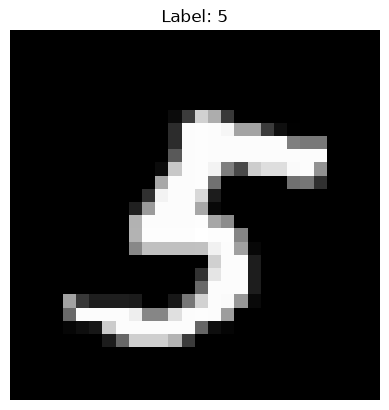

In [7]:
# Visualize the first sample image from the batch
import matplotlib.pyplot as plt

# Remove single-channel dimension (1, 28, 28) -> (28, 28) and render in grayscale
plt.imshow(images[0].squeeze(), cmap="gray")
plt.title(f"Label: {labels[0].item()}")
plt.axis("off")
plt.show()

### Task 4 — Create a Simple Network

In [ ]:
# Import neural network layers and optimization modules
from torch import nn, optim

# Define a feedforward neural network architecture
class SimpleNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        # Reshape input image: (32, 1, 28, 28) → (32, 784)
        self.flatten = nn.Flatten()

        # Fully connected hidden layer mapping 784 inputs to 128 features
        self.hidden = nn.Linear(28 * 28, 128)
        
        # Non-linear activation function
        self.relu = nn.ReLU()
        
        # Output layer producing raw logits for 10 digit classes (0–9)
        self.output = nn.Linear(128, 10)

    # Define the data flow through the network
    def forward(self, x):
        x = self.flatten(x)
        x = self.hidden(x)
        x = self.relu(x)
        x = self.output(x)
        return x

# Instantiate the model
model = SimpleNetwork()

# Print the network architecture and tensor dimensions before and after flattening
print(model)
print("\nBefore flattening:", images.shape)
print("After flattening:", torch.flatten(images, start_dim=1).shape)

SimpleNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (hidden): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (output): Linear(in_features=128, out_features=10, bias=True)
)

Before flattening: torch.Size([32, 1, 28, 28])
After flattening: torch.Size([32, 784])


### Task 5 — Training Function

In [ ]:
def train_network(model, train_loader, epochs=5, learning_rate=0.01, momentum=0.9):

    # Loss function and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(
        model.parameters(),
        lr=learning_rate,
        momentum=momentum
    )

    # Track metrics per epoch
    epoch_losses = []
    epoch_accuracies = []

    for epoch in range(epochs):
        model.train()  # Set training mode

        # Epoch metrics tracking
        total_loss = 0
        correct = 0
        total = 0

        for batch_number, (images, labels) in enumerate(train_loader, start=1):

            optimizer.zero_grad()  # Reset gradients

            # Forward pass and loss calculation
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass and weight update
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            # Calculate batch accuracy
            predicted = torch.argmax(outputs, dim=1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            # Log progress every 200 batches
            if batch_number % 200 == 0:
                current_accuracy = 100 * correct / total

                print(
                    f"Epoch {epoch + 1}/{epochs} | "
                    f"Batch {batch_number}/{len(train_loader)} | "
                    f"Loss: {loss.item():.4f} | "
                    f"Accuracy: {current_accuracy:.2f}%"
                )

        # Compute epoch averages
        average_loss = total_loss / len(train_loader)
        accuracy = 100 * correct / total

        epoch_losses.append(average_loss)
        epoch_accuracies.append(accuracy)

        # Print epoch summary
        print(
            f"\nEnd of Epoch {epoch + 1} | "
            f"Average Loss: {average_loss:.4f} | "
            f"Accuracy: {accuracy:.2f}%\n"
        )

    return epoch_losses, epoch_accuracies

### Task 6 — Train the Network and Plot Results

Epoch 1/5 | Batch 200/1875 | Loss: 0.3848 | Accuracy: 72.88%
Epoch 1/5 | Batch 400/1875 | Loss: 0.2940 | Accuracy: 80.55%
Epoch 1/5 | Batch 600/1875 | Loss: 0.3602 | Accuracy: 83.80%
Epoch 1/5 | Batch 800/1875 | Loss: 0.2941 | Accuracy: 85.62%
Epoch 1/5 | Batch 1000/1875 | Loss: 0.2431 | Accuracy: 86.80%
Epoch 1/5 | Batch 1200/1875 | Loss: 0.1224 | Accuracy: 87.72%
Epoch 1/5 | Batch 1400/1875 | Loss: 0.0978 | Accuracy: 88.50%
Epoch 1/5 | Batch 1600/1875 | Loss: 0.1648 | Accuracy: 89.18%
Epoch 1/5 | Batch 1800/1875 | Loss: 0.2856 | Accuracy: 89.68%

End of Epoch 1 | Average Loss: 0.3571 | Accuracy: 89.83%

Epoch 2/5 | Batch 200/1875 | Loss: 0.1791 | Accuracy: 94.48%
Epoch 2/5 | Batch 400/1875 | Loss: 0.2547 | Accuracy: 94.76%
Epoch 2/5 | Batch 600/1875 | Loss: 0.3748 | Accuracy: 94.84%
Epoch 2/5 | Batch 800/1875 | Loss: 0.1778 | Accuracy: 94.97%
Epoch 2/5 | Batch 1000/1875 | Loss: 0.2491 | Accuracy: 94.98%
Epoch 2/5 | Batch 1200/1875 | Loss: 0.3024 | Accuracy: 95.08%
Epoch 2/5 | Batch 1

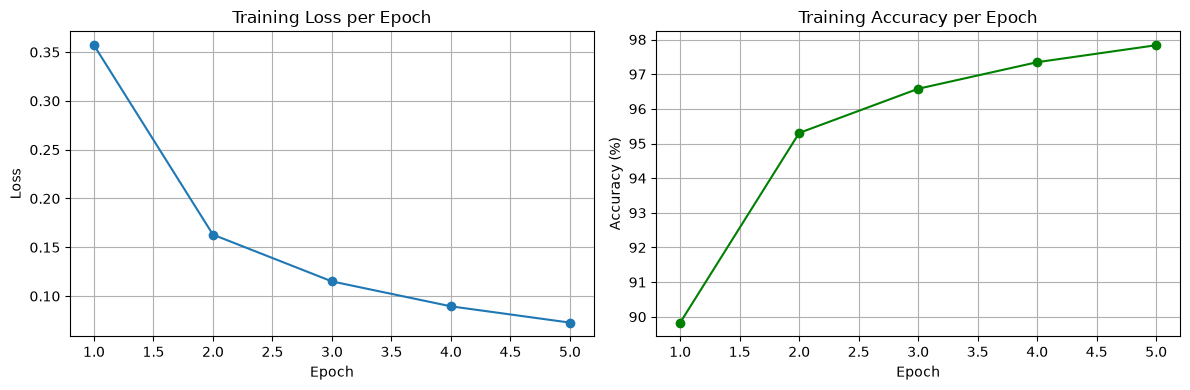

In [ ]:
# Create a fresh instance of the neural network
model = SimpleNetwork()

# Run the training loop across 5 epochs using SGD with momentum
epoch_losses, epoch_accuracies = train_network(
    model,
    train_loader,
    epochs=5,
    learning_rate=0.01,
    momentum=0.9
)

# Define x-axis values matching each completed epoch
epochs = range(1, len(epoch_losses) + 1)

# Set up a wide figure to hold two side-by-side metric subplots
plt.figure(figsize=(12, 4))

# Left subplot: Average cross-entropy loss per epoch
plt.subplot(1, 2, 1)
plt.plot(epochs, epoch_losses, marker="o")
plt.title("Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()

# Right subplot: Classification accuracy percentage per epoch
plt.subplot(1, 2, 2)
plt.plot(epochs, epoch_accuracies, marker="o", color="green")
plt.title("Training Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid()

# Automatically adjust spacing between plots and render the figure
plt.tight_layout()
plt.show()

### Task 7 — Test the Network

True labels:      [7, 2, 1, 0, 4, 1, 4, 9, 5, 9]
Predicted labels: [7, 2, 1, 0, 4, 1, 4, 9, 6, 9]


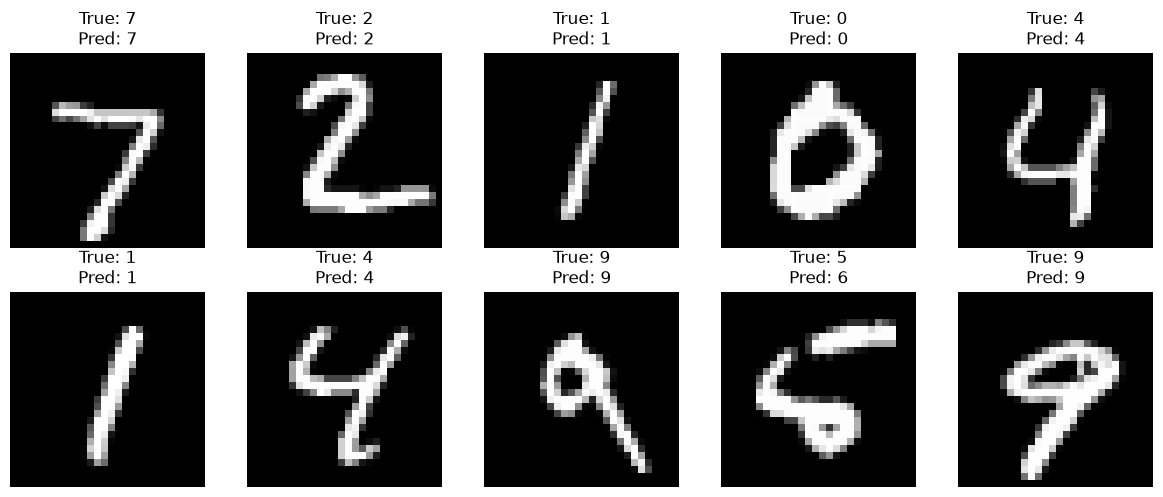

In [ ]:
# Set model to evaluation mode (disables dropout/batchnorm training behavior)
model.eval()

# Retrieve a single batch of test samples and labels
test_images, test_labels = next(iter(test_loader))

# Disable gradient calculation for faster inference and lower memory usage
with torch.no_grad():
    test_outputs = model(test_images)              # Forward pass (raw logits)
    predictions = torch.argmax(test_outputs, dim=1)  # Get predicted class indices

# Print side-by-side ground truth vs predictions for the first 10 images
print("True labels:     ", test_labels[:10].tolist())
print("Predicted labels:", predictions[:10].tolist())

# Create a figure grid (2 rows x 5 columns) to display images
plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    # Render 28x28 grayscale image
    plt.imshow(test_images[i].squeeze(), cmap="gray")
    
    # Label each image with actual and predicted digit
    plt.title(
        f"True: {test_labels[i].item()}\n"
        f"Pred: {predictions[i].item()}"
    )
    plt.axis("off")  # Remove axis ticks and borders

# Format subplot padding and display the visual results
plt.tight_layout()
plt.show()